In [2]:
from fastai.vision.all import *

In [3]:
path = untar_data(URLs.CAMVID_TINY)
path.ls()

(#3) [Path('/root/.fastai/data/camvid_tiny/codes.txt'),Path('/root/.fastai/data/camvid_tiny/images'),Path('/root/.fastai/data/camvid_tiny/labels')]

In [4]:
codes = np.loadtxt(path/'codes.txt', dtype=str)
codes

array(['Animal', 'Archway', 'Bicyclist', 'Bridge', 'Building', 'Car',
       'CartLuggagePram', 'Child', 'Column_Pole', 'Fence', 'LaneMkgsDriv',
       'LaneMkgsNonDriv', 'Misc_Text', 'MotorcycleScooter', 'OtherMoving',
       'ParkingBlock', 'Pedestrian', 'Road', 'RoadShoulder', 'Sidewalk',
       'SignSymbol', 'Sky', 'SUVPickupTruck', 'TrafficCone',
       'TrafficLight', 'Train', 'Tree', 'Truck_Bus', 'Tunnel',
       'VegetationMisc', 'Void', 'Wall'], dtype='<U17')

In [5]:
fnames = get_image_files(path/"images")
fnames[0]

Path('/root/.fastai/data/camvid_tiny/images/0016E5_08009.png')

In [6]:
(path/"labels").ls()[0]

Path('/root/.fastai/data/camvid_tiny/labels/0001TP_009840_P.png')

In [7]:
def label_func(fn): return path/"labels"/f"{fn.stem}_P{fn.suffix}"

In [8]:
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = fnames, label_func = label_func, codes = codes
)

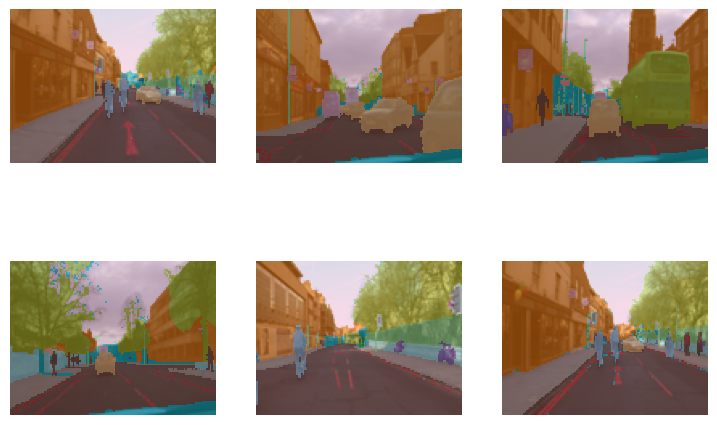

In [9]:
dls.show_batch(max_n=6)

In [11]:
learn = unet_learner(dls, resnet34)
learn.fine_tune(6)

epoch,train_loss,valid_loss,time
0,2.859415,2.733068,00:01


epoch,train_loss,valid_loss,time
0,2.053236,1.614664,00:01
1,1.796208,1.342734,00:01
2,1.615057,1.195158,00:01
3,1.450090,1.078477,00:01
4,1.316156,0.988203,00:01
5,1.213421,0.970915,00:01


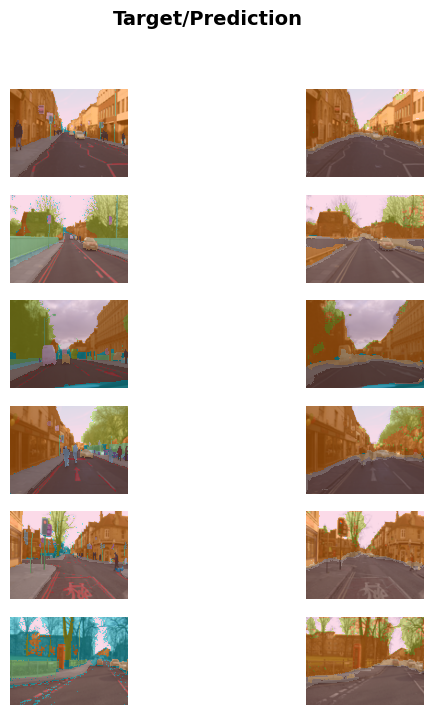

In [12]:
learn.show_results(max_n=6, figsize=(7,8))

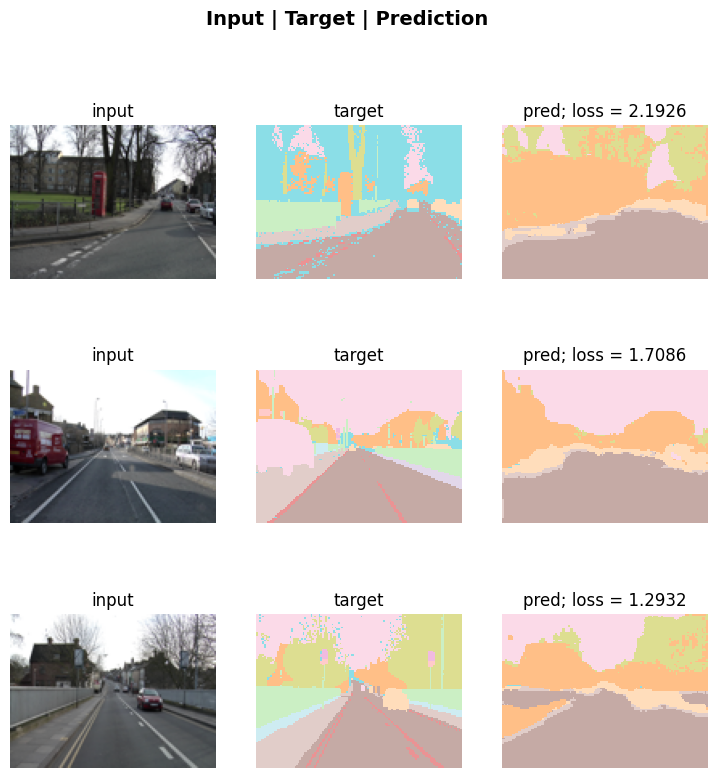

In [13]:
interp = SegmentationInterpretation.from_learner(learn)
interp.plot_top_losses(k=3)

#**With DataBlock API**

In [14]:
camvid = DataBlock(blocks=(ImageBlock, MaskBlock(codes)),
                   get_items = get_image_files,
                   get_y = label_func,
                   splitter=RandomSplitter(),
                   batch_tfms=aug_transforms(size=(120,160)))

In [15]:
dls = camvid.dataloaders(path/"images", path=path, bs=8)

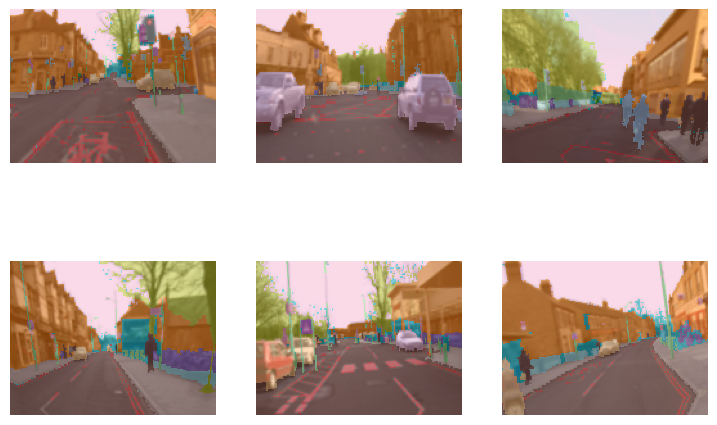

In [16]:
dls.show_batch(max_n=6)